In [15]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

#fits_name = "astronet_hlsp_qlp_tess_ffi-s0085-0000000418184767_tess_v01_llc.fits"
fits_name = "mk_hlsp_qlp_tess_ffi-s0012-0000000145525428_tess_v01_llc.fits"
fits1_path = f"/pdo/astronet-data/data/fits/oct2025_dataset_all_fits_files/{fits_name}"
fits2_path = f"/pdo/astronet-data/data/fits/oct2025_dataset_all_fits_files_30min_bin/{fits_name}"

with fits.open(fits2_path) as hdul:
    data = hdul["LIGHTCURVE"].data
    
    # List columns
    print("Original columns:", data.columns.names)
    
    # Extract key columns
    time = data["TIME"] + 2457000
    flux = data["SAP_FLUX"]
    cad  = data["CADENCENO"]
    q    = data["QUALITY"]

    # --- Diagnostics ---
    print(f"Time range: {np.nanmin(time):.5f} -> {np.nanmax(time):.5f}  ({len(time)} points)")
    print(f"Number of NaNs: TIME={np.isnan(time).sum()}, FLUX={np.isnan(flux).sum()}, CAD={np.isnan(cad).sum()}, Q={np.isnan(q).sum()}")

    # Check for zeros (potential div-by-zero sources)
    print(f"Number of zeros: FLUX={(flux==0).sum()}, TIMEΔ={(np.diff(time)==0).sum()}")

    # Summary stats (ignoring NaNs)
    def safe_stats(arr, name):
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size == 0:
            print(f"{name}: all NaN or invalid")
        else:
            print(f"{name}: min={np.nanmin(arr):.5g}, max={np.nanmax(arr):.5g}, mean={np.nanmean(arr):.5g}, median={np.nanmedian(arr):.5g}")

    print("\nSummary statistics:")
    safe_stats(flux, "FLUX")
    safe_stats(time, "TIME")
    safe_stats(cad, "CADENCENO")
    safe_stats(q, "QUALITY")

Original columns: ['TIME', 'CADENCENO', 'QUALITY', 'SAP_FLUX', 'SAP_FLUX_SML', 'SAP_FLUX_MID', 'SAP_FLUX_LAG', 'PERBIN_COUNTS']
Time range: 2458625.23465 -> 2458652.85965  (912 points)
Number of NaNs: TIME=0, FLUX=0, CAD=0, Q=0
Number of zeros: FLUX=0, TIMEΔ=0

Summary statistics:
FLUX: min=0.97835, max=1.0111, mean=1, median=1
TIME: min=2.4586e+06, max=2.4587e+06, mean=2.4586e+06, median=2.4586e+06
CADENCENO: min=0, max=911, mean=455.5, median=455.5
QUALITY: min=0, max=0, mean=0, median=0


Original columns: ['TIME', 'CADENCENO', 'SAP_FLUX', 'QUALITY', 'SAP_FLUX_SML', 'SAP_FLUX_MID', 'SAP_FLUX_LAG']
Rebinned columns: ['TIME', 'CADENCENO', 'QUALITY', 'SAP_FLUX', 'SAP_FLUX_SML', 'SAP_FLUX_MID', 'SAP_FLUX_LAG', 'PERBIN_COUNTS']
Original points: 17859, Rebinned points: 3214
Original flux: mean=1.003, std=0.086
Rebinned flux: mean=1.000, std=0.003


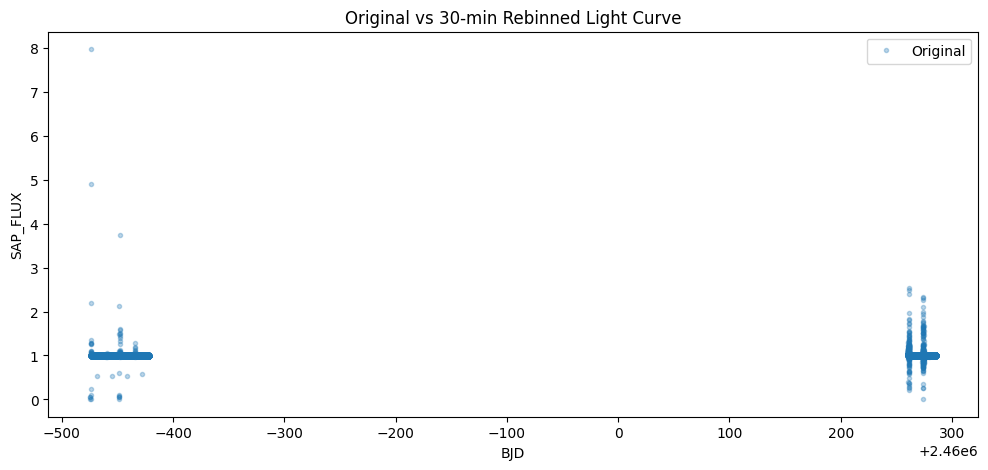

Flux difference statistics: mean=0.004, std=0.059


In [3]:



# --- Open FITS files ---
with fits.open(fits1_path) as hdul1, fits.open(fits2_path) as hdul2:
    data1 = hdul1["LIGHTCURVE"].data
    data2 = hdul2["LIGHTCURVE"].data
    
    # List columns
    print("Original columns:", data1.columns.names)
    print("Rebinned columns:", data2.columns.names)
    
    # Extract key columns
    time1 = data1["TIME"] + 2457000
    flux1 = data1["SAP_FLUX"]
    cad1  = data1["CADENCENO"]
    q1    = data1["QUALITY"]
    
    time2 = data2["TIME"] + 2457000
    flux2 = data2["SAP_FLUX"]
    cad2  = data2["CADENCENO"]
    q2    = data2["QUALITY"]
    
# --- Compare sizes ---
print(f"Original points: {len(time1)}, Rebinned points: {len(time2)}")

# --- Quick statistics ---
print(f"Original flux: mean={np.nanmean(flux1):.3f}, std={np.nanstd(flux1):.3f}")
print(f"Rebinned flux: mean={np.nanmean(flux2):.3f}, std={np.nanstd(flux2):.3f}")

# --- Plot to visually compare ---
plt.figure(figsize=(12,5))
plt.plot(time1, flux1, '.', alpha=0.3, label='Original')
#plt.plot(time2, flux2, '.', label='30-min Rebinned')
plt.xlabel("BJD")
plt.ylabel("SAP_FLUX")
plt.title("Original vs 30-min Rebinned Light Curve")
plt.legend()
plt.show()

# --- Optional: Check flux differences at overlapping times ---
# Interpolate rebinned flux back to original times
from scipy.interpolate import interp1d

interp_flux2 = interp1d(time2, flux2, kind='linear', bounds_error=False, fill_value=np.nan)
flux2_on_orig = interp_flux2(time1)
diff = flux1 - flux2_on_orig

print(f"Flux difference statistics: mean={np.nanmean(diff):.3f}, std={np.nanstd(diff):.3f}")

In [12]:
import json
from pprint import pprint

with open(fits2_path.replace(".fits", ".json"), "r", encoding="utf-8") as file:
    data = json.load(file)

def summarize(obj, max_items=10, max_depth=2, _depth=0):
    """Return a compact JSON-like string showing a few examples per key."""
    indent = "  " * _depth

    if isinstance(obj, dict):
        items = list(obj.items())
        shown = []
        for k, v in items[:max_items]:
            shown.append(f'\n{indent}  "{k}": {summarize(v, max_items, max_depth, _depth + 1)}')
        if len(items) > max_items:
            shown.append(f"\n{indent}  ...")
        return "{" + "".join(shown) + f"\n{indent}" + "}"

    elif isinstance(obj, list):
        if not obj:
            return "[]"
        shown = [summarize(v, max_items, max_depth, _depth + 1) for v in obj[:max_items]]
        body = ", ".join(shown)
        if len(obj) > max_items:
            body += ", ..."
        return "[" + body + "]"

    else:
        # Primitives (string, number, bool, None)
        if isinstance(obj, str):
            s = obj.replace("\n", " ")
            if len(s) > 80:
                s = s[:77] + "..."
            return json.dumps(s)
        return json.dumps(obj)

# --- Print summary ---
print(summarize(data))


{
  "original_fits_location": "/pdo/astronet-data/data/fits/oct2025_dataset_all_fits_files/astronet_hlsp_qlp..."
  "SAP_FLUX": {
    "segments": [{
        "point_start_index": 0
        "point_end_index": 561
        "start_bjd": 2458517.369845858
        "end_bjd": 2458529.0573436506
        "n_points": 562
        "n_deltas": 561
        "cadence_median_min": 30.00001162290573
        "cadence_err_min": 0.00027935917675495146
        "cadence_classified_min": 30.0
      }, {
        "point_start_index": 562
        "point_end_index": 631
        "start_bjd": 2458530.286491147
        "end_bjd": 2458531.723978285
        "n_points": 70
        "n_deltas": 69
        "cadence_median_min": 29.99973602592945
        "cadence_err_min": 1.1929929256439208e-05
        "cadence_classified_min": 30.0
      }, {
        "point_start_index": 632
        "point_end_index": 967
        "start_bjd": 2458535.0156039135
        "end_bjd": 2458541.9946058993
        "n_points": 336
        "n_deltas